# Setup: define f(x)=x on (-pi,pi), Fourier sine coefficients, and partial sums


In [61]:

import numpy as np
import matplotlib.pyplot as plt

# Domain for one period: [-pi, pi]
pi = np.pi
M = 4000
x = np.linspace(-pi, pi, M, endpoint=False)

# Target function on (-pi, pi): identity
f = x.copy()

def b_n(n: int) -> float:
    """
    Fourier sine coefficient for f(x)=x on (-pi,pi) with 2pi-periodic extension:
    f(x) = sum_{n>=1} b_n sin(n x)
    Known closed form: b_n = 2 * (-1)^{n+1} / n
    """
    return 2.0 * ((-1.0) ** (n + 1)) / n

def partial_sum(N: int, xgrid: np.ndarray) -> np.ndarray:
    """S_N(x) = sum_{n=1}^N b_n sin(n x)."""
    S = np.zeros_like(xgrid, dtype=float)
    for n in range(1, N + 1):
        S += b_n(n) * np.sin(n * xgrid)
    return S

# Example partial sums to visualize later
Ns = [1, 3, 5, 10, 25, 50]
S_list = [partial_sum(N, x) for N in Ns]

print("Ready. Next cell will plot modes and truncated approximations.")


Ready. Next cell will plot modes and truncated approximations.


# Plot (a) individual modes b_n sin(nx) and (b) truncated series S_N(x) vs f(x)


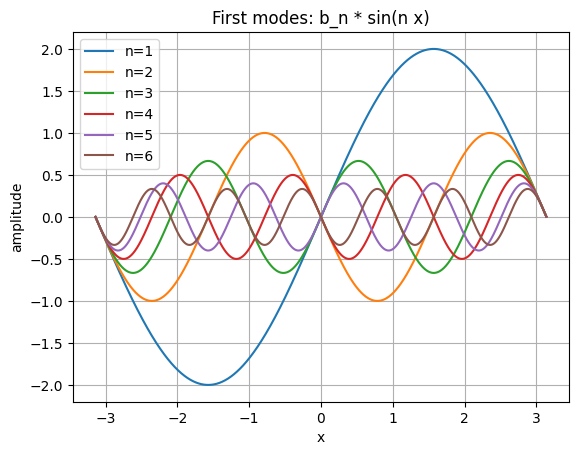

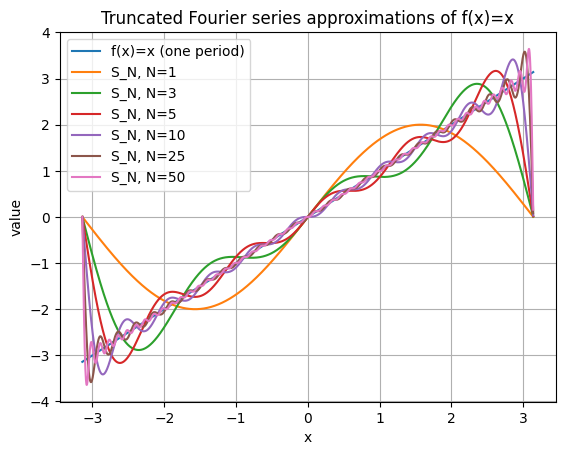

In [62]:

# Choose how many modes to show
K = 6  # show first 6 modes

# (a) Plot first few individual modes
plt.figure()
for n in range(1, K + 1):
    mode = b_n(n) * np.sin(n * x)
    plt.plot(x, mode, label=f"n={n}")
plt.title("First modes: b_n * sin(n x)")
plt.xlabel("x")
plt.ylabel("amplitude")
plt.legend()
plt.grid(True)
plt.show()

# (b) Plot truncated series vs the target function
plt.figure()
plt.plot(x, f, label="f(x)=x (one period)")
for N, S in zip(Ns, S_list):
    plt.plot(x, S, label=f"S_N, N={N}")
plt.title("Truncated Fourier series approximations of f(x)=x")
plt.xlabel("x")
plt.ylabel("value")
plt.legend()
plt.grid(True)
plt.show()

# Tip: you'll see Gibbs oscillations near x = ±pi because the periodic extension has a jump there.


# Cell 3 — Plot coefficients and compute approximation errors vs $N$

In this cell, we do two things:

1. **Visualize the decay of the Fourier sine coefficients** $|b_n|$ for $f(x)=x$.
2. **Measure how well the truncated series $S_N(x)$ approximates $f(x)$** as we increase $N$.

---

## 3(a) Plot coefficient magnitudes $|b_n|$

We pick a maximum harmonic index $N_{\max}=200$ and compute
$$
b_n,\quad n=1,2,\dots,N_{\max}.
$$

Then we plot $b_n$ versus $n$.

### Intuition

- The coefficients $b_n$ tell us **how much of the sine wave $\sin(nx)$** is present in the function.
- For smooth functions, Fourier coefficients tend to decay fast.
- For functions with discontinuities (or periodic extensions with jumps), coefficients decay more slowly.

Here, even though $f(x)=x$ is smooth on $(-\pi,\pi)$, its **$2\pi$-periodic extension has a jump at $\pm \pi$**, which affects how fast $|b_n|$ decays.

---

## 3(b) Approximation error versus $N$

We evaluate the partial sums
$$
S_N(x) = \sum_{n=1}^{N} b_n \sin(nx)
$$
on a dense grid of $x$ values and compute the approximation error
$$
e_N(x) = S_N(x) - f(x).
$$

We report four error metrics for several values of $N$:

### Metrics

1. **RMS error on the full interval** $[-\pi,\pi)$:
$$
\mathrm{RMS}_{\text{full}}(N)
= \sqrt{\frac{1}{M}\sum_{k=1}^{M} e_N(x_k)^2 }.
$$

2. **RMS error on an interior region** that excludes a small boundary neighborhood near $\pm\pi$:
- We remove a strip of width $\delta$ near each boundary.
- The interior mask is:
$$
x \in (-\pi+\delta,\ \pi-\delta).
$$

3. **Maximum absolute error on the full interval**:
$$
\|e_N\|_{\infty,\text{full}} = \max_{x\in[-\pi,\pi)} |e_N(x)|.
$$

4. **Maximum absolute error on the interior interval**:
$$
\|e_N\|_{\infty,\text{int}} = \max_{x\in(-\pi+\delta,\ \pi-\delta)} |e_N(x)|.
$$

---

## Why full vs interior errors behave differently (Gibbs effect)

Because the $2\pi$-periodic extension of $f(x)=x$ has a **jump discontinuity at $\pm\pi$**, the Fourier partial sums exhibit **Gibbs oscillations** near the discontinuity:

- The **full-interval error** decreases slowly, because it includes the boundary region where the oscillations persist.
- The **interior error** drops much faster, because away from the jump the series converges much better.

This is why we plot both:
- Full interval errors: dominated by the discontinuity zone.
- Interior errors: reflect the “true” convergence away from the jump.

---

## Notes printed by the code

- Full-interval error decreases slowly because of the jump at $\pm\pi$ in the periodic extension (Gibbs).
- Interior error drops much faster away from the discontinuity.
- Max errors show the same behavior: they are larger near the discontinuities on the full interval.


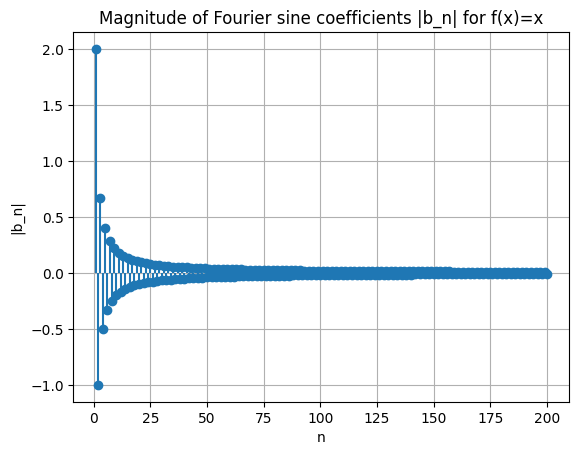

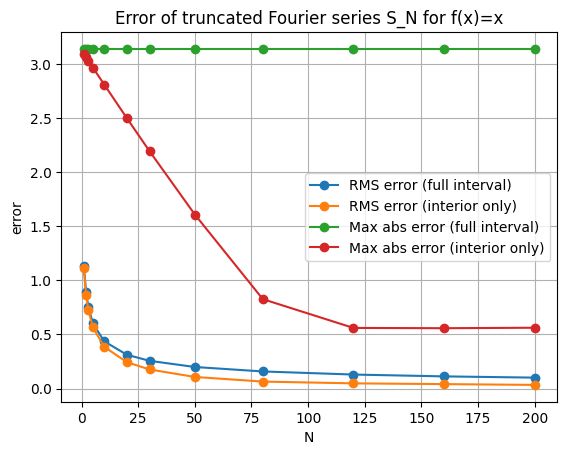

Notes:
- Full-interval error decreases slowly because of the jump at ±pi in the periodic extension (Gibbs).
- Interior error drops much faster away from the discontinuity.
- Max errors show the same behavior: larger near the discontinuities on the full interval.


In [63]:

# Cell 3 — Plot coefficients and compute approximation errors vs N

# (a) Coefficients magnitude |b_n| for n=1..Nmax
Nmax = 200
n_vals = np.arange(1, Nmax + 1)
b_vals = np.array([b_n(n) for n in n_vals])

plt.figure()
plt.stem(n_vals, b_vals, basefmt=" ")
plt.title("Magnitude of Fourier sine coefficients |b_n| for f(x)=x")
plt.xlabel("n")
plt.ylabel("|b_n|")
plt.grid(True)
plt.show()

# (b) Error vs N
# We'll compute:
#  - RMS error over the full interval [-pi,pi)
#  - "interior" RMS error excluding a small boundary region to reduce Gibbs-dominated error
#  - Max abs error on both full and interior intervals
def rms(a: np.ndarray) -> float:
    return float(np.sqrt(np.mean(a * a)))

# Exclude boundary neighborhood of width delta around ±pi
delta = 0.015  # you can change this
mask_interior = (x > -pi + delta) & (x < pi - delta)

N_grid = [1, 2, 3, 5, 10, 20, 30, 50, 80, 120, 160, 200]
rms_full = []
rms_interior = []
max_full = []
max_interior = []

for N in N_grid:
    S = partial_sum(N, x)
    err = S - f
    rms_full.append(rms(err))
    rms_interior.append(rms(err[mask_interior]))
    max_full.append(float(np.max(np.abs(err))))
    max_interior.append(float(np.max(np.abs(err[mask_interior]))))

plt.figure()
plt.plot(N_grid, rms_full, marker="o", label="RMS error (full interval)")
plt.plot(N_grid, rms_interior, marker="o", label="RMS error (interior only)")
plt.plot(N_grid, max_full, marker="o", label="Max abs error (full interval)")
plt.plot(N_grid, max_interior, marker="o", label="Max abs error (interior only)")
plt.title("Error of truncated Fourier series S_N for f(x)=x")
plt.xlabel("N")
plt.ylabel("error")
plt.legend()
plt.grid(True)
plt.show()

print("Notes:")
print("- Full-interval error decreases slowly because of the jump at ±pi in the periodic extension (Gibbs).")
print("- Interior error drops much faster away from the discontinuity.")
print("- Max errors show the same behavior: larger near the discontinuities on the full interval.")


## Triangle function: definition and conventions

We study the **triangle (tent) function**
$$
\operatorname{tri}(t)=
\begin{cases}
1-|t|, & |t|\le 1, \\
0, & |t|>1.
\end{cases}
$$


This function is:
- even,
- compactly supported on \([-1,1]\),
- continuous but not differentiable at \(t=0\).

We will:
1. Compute its **continuous Fourier transform** using exact formulas.
2. Compute its **Fourier series** for the periodic extension of period \(2\).
3. Compare exact truncation errors.
4. Compare the **exact continuous FT** with a **DFT-based approximation** obtained from sampled data.

All formulas used are exact (no asymptotic or heuristic arguments).


## FT and Fourier coefficients when the period T increases

For the triangle function supported on $[-1,1]$:
$$
F(\omega)=\int_{-\infty}^{\infty} f(t)e^{-i\omega t}\,dt
=\left(\frac{\sin(\omega/2)}{\omega/2}\right)^2
$$

For the periodic extension with period $T$ (pulse on $[-1,1]$, zero elsewhere in one period),
the Fourier series frequencies are
$$
\omega_n=\frac{2\pi n}{T}
$$
and the coefficients satisfy the exact identity
$$
c_n^{(T)}=\frac{1}{T}F(\omega_n).
$$

Therefore the scaled coefficients satisfy
$$
T\,c_n^{(T)}=F(\omega_n),
$$
so as $T\to\infty$ the samples become denser on the $\omega$ axis.


## Continuous Fourier transform (exact)

$$
F(\omega)=\int_{-\infty}^{\infty} f(t)\,e^{-i\omega t}\,dt
$$

$$
F(\omega)=\left(\frac{\sin(\omega/2)}{\omega/2}\right)^2,
\qquad
F(0)=1
$$


## Fourier series for period T=2 (exact)

$$
f(x)=\frac{1}{2}+\sum_{n=1}^{\infty} a_n\cos(n\pi x)
$$

$$
a_n=\frac{2\left(1-(-1)^n\right)}{\pi^2 n^2}
$$

$$
a_n=0 \ \text{for even } n,
\qquad
a_n=\frac{4}{\pi^2 n^2} \ \text{for odd } n
$$


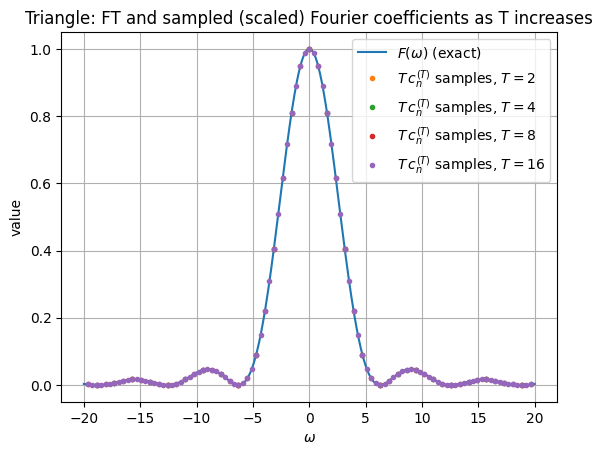

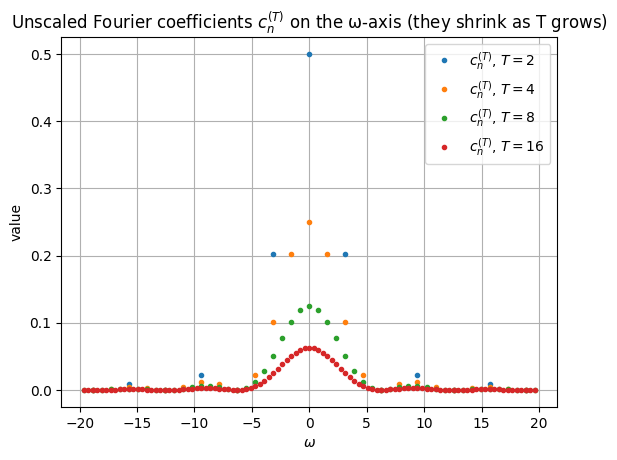

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Triangle function
# -----------------------
def tri(t):
    t = np.asarray(t)
    return np.maximum(1.0 - np.abs(t), 0.0)

# -----------------------
# Exact continuous FT (angular frequency ω)
# F(ω) = (sin(ω/2)/(ω/2))^2, with F(0)=1
# -----------------------
def FT_tri_omega(omega):
    omega = np.asarray(omega, dtype=float)
    out = np.empty_like(omega)
    z = omega / 2.0
    mask0 = (omega == 0.0)
    out[mask0] = 1.0
    out[~mask0] = (np.sin(z[~mask0]) / z[~mask0])**2
    return out

# -----------------------
# Fourier series coefficients for the "pulse + zeros" periodic extension
# Period = T, frequencies ω_n = 2π n / T
# Exact: c_n^(T) = (1/T) * F(ω_n)
# -----------------------
def coeffs_on_omega_axis(T, omega_max):
    # choose integer n so that ω_n lies in [-omega_max, omega_max]
    n_max = int(np.floor(omega_max * T / (2*np.pi)))
    n = np.arange(-n_max, n_max + 1)
    omega_n = 2*np.pi * n / T
    c_n = (1.0 / T) * FT_tri_omega(omega_n)   # exact, since tri is compactly supported
    return omega_n, c_n

# -----------------------
# Plot: continuous FT + discrete coefficients for different T
# We plot BOTH:
#   (1) scaled samples: T*c_n = F(ω_n)  (these lie on the FT curve)
#   (2) unscaled c_n (these go to 0 as T increases)
# -----------------------
omega_max = 20.0
omega = np.linspace(-omega_max, omega_max, 5000)
F = FT_tri_omega(omega)

Ts = [2.0, 4.0, 8.0, 16.0]  # increase as you like (must be >= 2 here)

plt.figure()
plt.plot(omega, F, label=r"$F(\omega)$ (exact)")

for T in Ts:
    omega_n, c_n = coeffs_on_omega_axis(T, omega_max)

    # scaled coefficients: should match F(ω_n) exactly
    plt.plot(omega_n, T * c_n, "o", markersize=3, label=fr"$T\,c_n^{{(T)}}$ samples, $T={T:g}$")

plt.xlabel(r"$\omega$")
plt.ylabel("value")
plt.title("Triangle: FT and sampled (scaled) Fourier coefficients as T increases")
plt.grid(True)
plt.legend()
plt.show()

# Optional: show unscaled coefficients on the same ω axis (they shrink like 1/T)
plt.figure()
for T in Ts:
    omega_n, c_n = coeffs_on_omega_axis(T, omega_max)
    plt.plot(omega_n, c_n, "o", markersize=3, label=fr"$c_n^{{(T)}}$, $T={T:g}$")
plt.xlabel(r"$\omega$")
plt.ylabel("value")
plt.title("Unscaled Fourier coefficients $c_n^{(T)}$ on the ω-axis (they shrink as T grows)")
plt.grid(True)
plt.legend()
plt.show()
